In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from datetime import datetime as dt

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [77]:
train_path = Path("../data/train.csv")
train = pd.read_csv(train_path)

print("Train dataset dimensions:")
print(train.shape)
print("First 5 rows of train dataset")
train.head()

Train dataset dimensions:
(1017209, 9)
First 5 rows of train dataset


C:\Users\luisd\AppData\Local\Temp\ipykernel_12408\648537543.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(train_path)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [78]:
store_path = Path("../data/store.csv")
store = pd.read_csv(store_path)

print("Store dataset dimensions:")
print(store.shape)
print("First 5 rows of store dataset:")
store.head()

Store dataset dimensions:
(1115, 10)
First 5 rows of store dataset:


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## Let's inspect the data types of the train dataset to make sure everything is in the correct data type 

In [79]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


### We can see that the Date column is of type string. Let's make it a datetime series
### In addition, we see that the StateHoliday column is of type object (string) it should be of type int since we want 1/0 values only, except for the cases where there is no data

In [80]:
train['Date'] = pd.to_datetime(train['Date'] , format= "%Y-%m-%d")
train['StateHoliday'] =train['StateHoliday'].isin(['a', 'b', 'c']).astype(int)

## Now let's repeat this process for the store dataset

In [81]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [82]:
store['Promo2SinceWeek'] = store['Promo2SinceWeek'].fillna(-1).astype('int64')
store['Promo2SinceYear'] = store['Promo2SinceYear'].fillna(-1).astype('int64')
store['CompetitionOpenSinceYear'] = store['CompetitionOpenSinceYear'].fillna(-1).astype('int64')
store = store.join(pd.get_dummies(
    pd.to_datetime(
        store['CompetitionOpenSinceMonth'],
          format='%m'
          ).dt.month_name(),
          drop_first=True,
          prefix='Competition_open_since'
    ).astype('int64')
)
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,...,Competition_open_since_December,Competition_open_since_February,Competition_open_since_January,Competition_open_since_July,Competition_open_since_June,Competition_open_since_March,Competition_open_since_May,Competition_open_since_November,Competition_open_since_October,Competition_open_since_September
0,1,c,a,1270.0,9.0,2008,0,-1,-1,NaN,...,0,0,0,0,0,0,0,0,0,1
1,2,a,a,570.0,11.0,2007,1,13,2010,"Jan,Apr,Jul,Oct",...,0,0,0,0,0,0,0,1,0,0
2,3,a,a,14130.0,12.0,2006,1,14,2011,"Jan,Apr,Jul,Oct",...,1,0,0,0,0,0,0,0,0,0
3,4,c,c,620.0,9.0,2009,0,-1,-1,NaN,...,0,0,0,0,0,0,0,0,0,1
4,5,a,a,29910.0,4.0,2015,0,-1,-1,NaN,...,0,0,0,0,0,0,0,0,0,0


In [83]:
# Directly create dummies from the string column
dummies = (
    store['PromoInterval']
    .str.get_dummies(sep=',')   # create dummies from comma-separated strings
    .add_prefix('Promo2_Interval_in_')    # add prefix
)

# Drop the first dummy column (like drop_first=True)
dummies = dummies.iloc[:, 1:]

# Join back to the store dataframe
store = store.join(dummies)

store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,...,Promo2_Interval_in_Dec,Promo2_Interval_in_Feb,Promo2_Interval_in_Jan,Promo2_Interval_in_Jul,Promo2_Interval_in_Jun,Promo2_Interval_in_Mar,Promo2_Interval_in_May,Promo2_Interval_in_Nov,Promo2_Interval_in_Oct,Promo2_Interval_in_Sept
0,1,c,a,1270.0,9.0,2008,0,-1,-1,NaN,...,0,0,0,0,0,0,0,0,0,0
1,2,a,a,570.0,11.0,2007,1,13,2010,"Jan,Apr,Jul,Oct",...,0,0,1,1,0,0,0,0,1,0
2,3,a,a,14130.0,12.0,2006,1,14,2011,"Jan,Apr,Jul,Oct",...,0,0,1,1,0,0,0,0,1,0
3,4,c,c,620.0,9.0,2009,0,-1,-1,NaN,...,0,0,0,0,0,0,0,0,0,0
4,5,a,a,29910.0,4.0,2015,0,-1,-1,NaN,...,0,0,0,0,0,0,0,0,0,0


In [84]:
store.columns

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval',
       'Competition_open_since_August', 'Competition_open_since_December',
       'Competition_open_since_February', 'Competition_open_since_January',
       'Competition_open_since_July', 'Competition_open_since_June',
       'Competition_open_since_March', 'Competition_open_since_May',
       'Competition_open_since_November', 'Competition_open_since_October',
       'Competition_open_since_September', 'Promo2_Interval_in_Aug',
       'Promo2_Interval_in_Dec', 'Promo2_Interval_in_Feb',
       'Promo2_Interval_in_Jan', 'Promo2_Interval_in_Jul',
       'Promo2_Interval_in_Jun', 'Promo2_Interval_in_Mar',
       'Promo2_Interval_in_May', 'Promo2_Interval_in_Nov',
       'Promo2_Interval_in_Oct', 'Promo2_Interval_in_Sept'],
      dtype='object')

In [85]:
drop_cols = ['CompetitionOpenSinceMonth' , 'PromoInterval']
store = store.drop(columns=drop_cols)
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,Competition_open_since_August,Competition_open_since_December,...,Promo2_Interval_in_Dec,Promo2_Interval_in_Feb,Promo2_Interval_in_Jan,Promo2_Interval_in_Jul,Promo2_Interval_in_Jun,Promo2_Interval_in_Mar,Promo2_Interval_in_May,Promo2_Interval_in_Nov,Promo2_Interval_in_Oct,Promo2_Interval_in_Sept
0,1,c,a,1270.0,2008,0,-1,-1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,a,a,570.0,2007,1,13,2010,0,0,...,0,0,1,1,0,0,0,0,1,0
2,3,a,a,14130.0,2006,1,14,2011,0,1,...,0,0,1,1,0,0,0,0,1,0
3,4,c,c,620.0,2009,0,-1,-1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,a,a,29910.0,2015,0,-1,-1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [86]:
df = train.join(store.set_index('Store'), on = 'Store' , how='left')
df['Store'] = pd.Categorical(df['Store'])
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2_Interval_in_Dec,Promo2_Interval_in_Feb,Promo2_Interval_in_Jan,Promo2_Interval_in_Jul,Promo2_Interval_in_Jun,Promo2_Interval_in_Mar,Promo2_Interval_in_May,Promo2_Interval_in_Nov,Promo2_Interval_in_Oct,Promo2_Interval_in_Sept
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,0,0,0,0,0,0,0,0,0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,0,0,1,1,0,0,0,0,1,0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,0,0,1,1,0,0,0,0,1,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,0,0,0,0,0,0,0,0,0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,0,0,0,0,0,0,0,0,0,0


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 38 columns):
 #   Column                            Non-Null Count    Dtype         
---  ------                            --------------    -----         
 0   Store                             1017209 non-null  category      
 1   DayOfWeek                         1017209 non-null  int64         
 2   Date                              1017209 non-null  datetime64[ns]
 3   Sales                             1017209 non-null  int64         
 4   Customers                         1017209 non-null  int64         
 5   Open                              1017209 non-null  int64         
 6   Promo                             1017209 non-null  int64         
 7   StateHoliday                      1017209 non-null  int64         
 8   SchoolHoliday                     1017209 non-null  int64         
 9   StoreType                         1017209 non-null  object        
 10  Assortment        

In [88]:
df['Sales'] = df['Sales'].astype('float64')
df['Customers'] = df['Customers'].astype('float64')
df = df.set_index('Date').sort_index()
df.index

DatetimeIndex(['2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01',
               ...
               '2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31'],
              dtype='datetime64[ns]', name='Date', length=1017209, freq=None)

In [89]:
df['Month'] = df.index.month
df['Year'] = df.index.year
df['Day'] = df.index.day

df.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,Promo2_Interval_in_Jul,Promo2_Interval_in_Jun,Promo2_Interval_in_Mar,Promo2_Interval_in_May,Promo2_Interval_in_Nov,Promo2_Interval_in_Oct,Promo2_Interval_in_Sept,Month,Year,Day
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,1115,2,0.0,0.0,0,0,1,1,d,c,...,0,1,1,0,0,0,1,1,2013,1
2013-01-01,379,2,0.0,0.0,0,0,1,1,d,a,...,0,0,0,0,0,0,0,1,2013,1
2013-01-01,378,2,0.0,0.0,0,0,1,1,a,c,...,0,0,0,0,0,0,0,1,2013,1
2013-01-01,377,2,0.0,0.0,0,0,1,1,a,c,...,0,0,0,1,1,0,0,1,2013,1
2013-01-01,376,2,0.0,0.0,0,0,1,1,a,a,...,0,0,0,0,0,0,0,1,2013,1


In [90]:
# Now let's create lagged sales features to include in the model
lags = [1, 7, 14, 28, 365]

for lag in lags:
    df[f"Sales_lag{lag}"] = df.groupby("Store", observed=True)["Sales"].shift(lag)
    df[f"Customers_lag{lag}"] = df.groupby("Store", observed=True)["Customers"].shift(lag)

df = df.drop(columns='Customers')


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1017209 entries, 2013-01-01 to 2015-07-31
Data columns (total 49 columns):
 #   Column                            Non-Null Count    Dtype   
---  ------                            --------------    -----   
 0   Store                             1017209 non-null  category
 1   DayOfWeek                         1017209 non-null  int64   
 2   Sales                             1017209 non-null  float64 
 3   Open                              1017209 non-null  int64   
 4   Promo                             1017209 non-null  int64   
 5   StateHoliday                      1017209 non-null  int64   
 6   SchoolHoliday                     1017209 non-null  int64   
 7   StoreType                         1017209 non-null  object  
 8   Assortment                        1017209 non-null  object  
 9   CompetitionDistance               1014567 non-null  float64 
 10  CompetitionOpenSinceYear          1017209 non-null  int64   
 11  Promo2   

In [92]:
float_feats = df.select_dtypes(include='float64').columns
print(float_feats)

Index(['Sales', 'CompetitionDistance', 'Sales_lag1', 'Customers_lag1',
       'Sales_lag7', 'Customers_lag7', 'Sales_lag14', 'Customers_lag14',
       'Sales_lag28', 'Customers_lag28', 'Sales_lag365', 'Customers_lag365'],
      dtype='object')


In [93]:
def plot_hist_grid(df, cols, include_feature_summary=True):
    """
    Plot a grid of histograms for the given columns.
    Optionally returns a summary DataFrame with mean and median per feature.
    """
    n = len(cols)
    if n == 0:
        return None

    # Compute grid size
    y = int(np.sqrt(n))
    x = int(np.ceil(n / y))

    fig, axes = plt.subplots(
        nrows=y,
        ncols=x,
        figsize=(16, 10),
        sharex=False,
        sharey=False
    )

    # Ensure axes is always a flat array
    if n == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    # Collect summary rows here (more efficient than concat in a loop)
    feature_rows = []

    for i, col in enumerate(cols):
        ax = axes[i]

        # Drop NaNs for plotting and stats
        series = df[col].dropna()

        sns.histplot(series, kde=True, ax=ax, stat='frequency')

        mean_val = series.mean()
        median_val = series.median()

        if include_feature_summary:
            feature_rows.append({
                'Feature': col,
                'mean_val': mean_val,
                'median_val': median_val
            })

        # Vertical dashed lines: mean (red) and median (green)
        ax.axvline(mean_val, color="red", linestyle="--", linewidth=1, label="Mean")
        ax.axvline(median_val, color="green", linestyle="--", linewidth=1, label="Median")

        # Only show legend once (first subplot)
        if i == 0:
            ax.legend()

        ax.set_title(f"Histogram of {col}")

    # Hide any unused axes (if grid has more cells than cols)
    for j in range(n, x * y):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

    if include_feature_summary:
        features_summ = pd.DataFrame(feature_rows)
        return features_summ
    else:
        return None

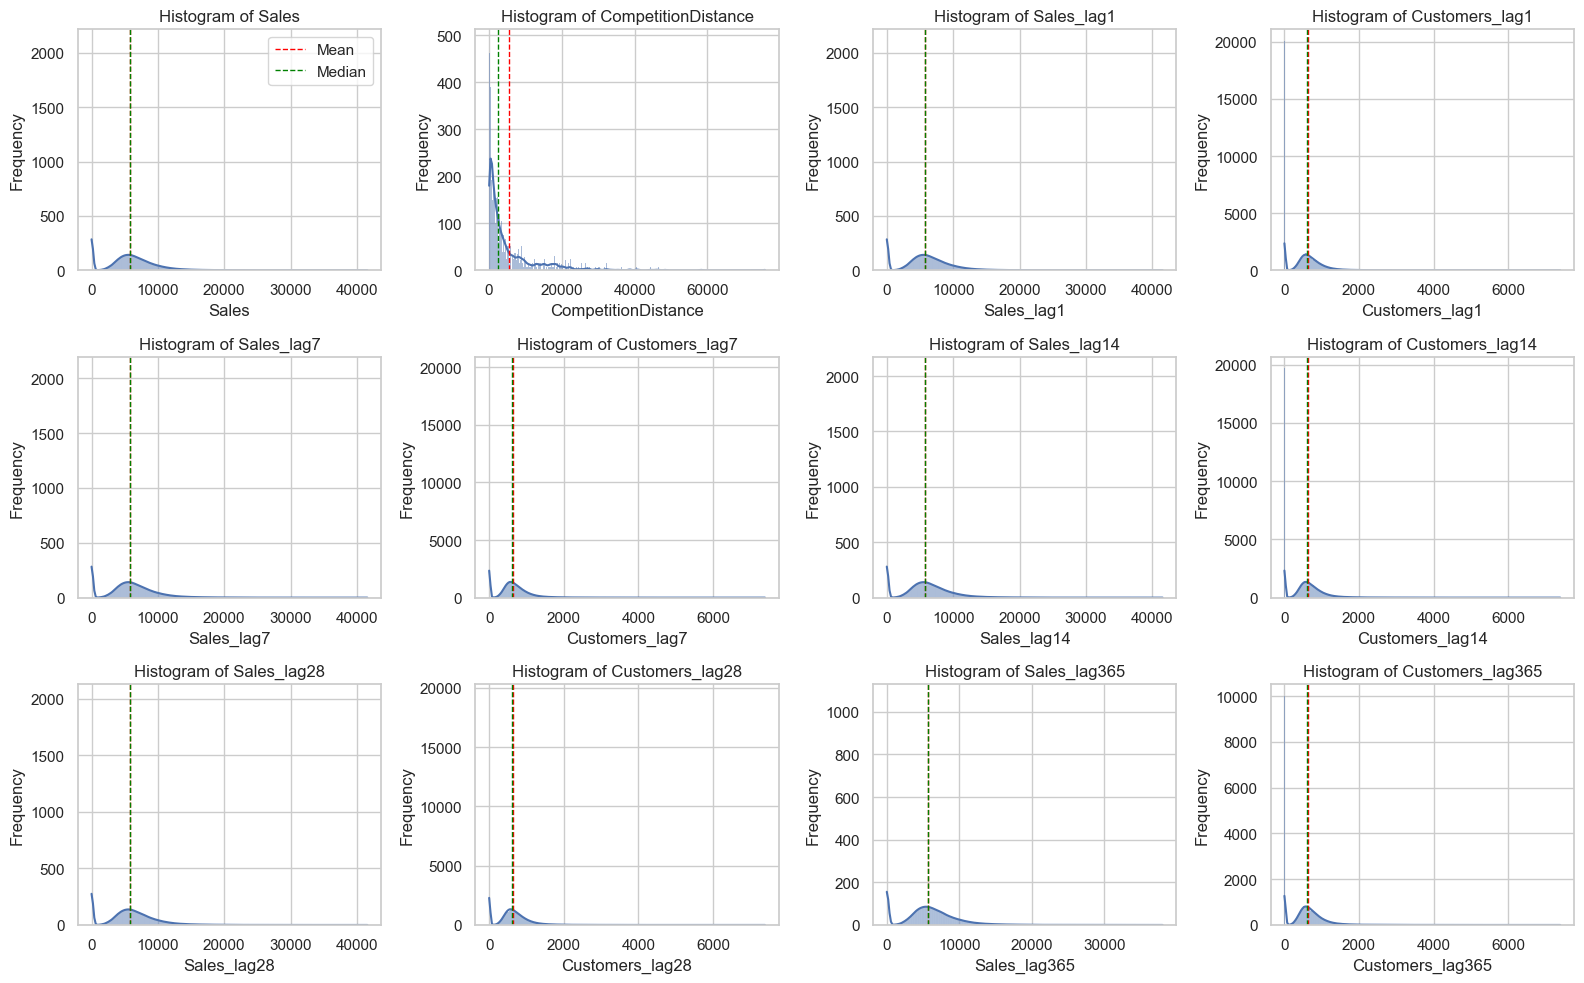

In [94]:
features_summ = plot_hist_grid(df, float_feats, include_feature_summary=True)

## Since it's hard to see the difference between the mean and the median value

### We'll loop over the `features_summ` dataframe and apply:

- **If `mean < median`:**
  - `x = log(x + 1)`

- **Else if `median < mean`:**
  - `x = sqrt(x)`
- **Else:**
  - `do nothing`


In [95]:
for i, row in features_summ.iterrows():
    if row['mean_val'] < row['median_val']:
        df[row['Feature']] = np.log(df[row['Feature']] + 1)
        df = df.rename(columns={row['Feature']: f"log_{row['Feature']}"})
    elif row['mean_val'] > row['median_val']:
        df[row['Feature']] = np.sqrt(df[row['Feature']])
        df = df.rename(columns={row['Feature']: f"sqrt_{row['Feature']}"})
    else:
        continue


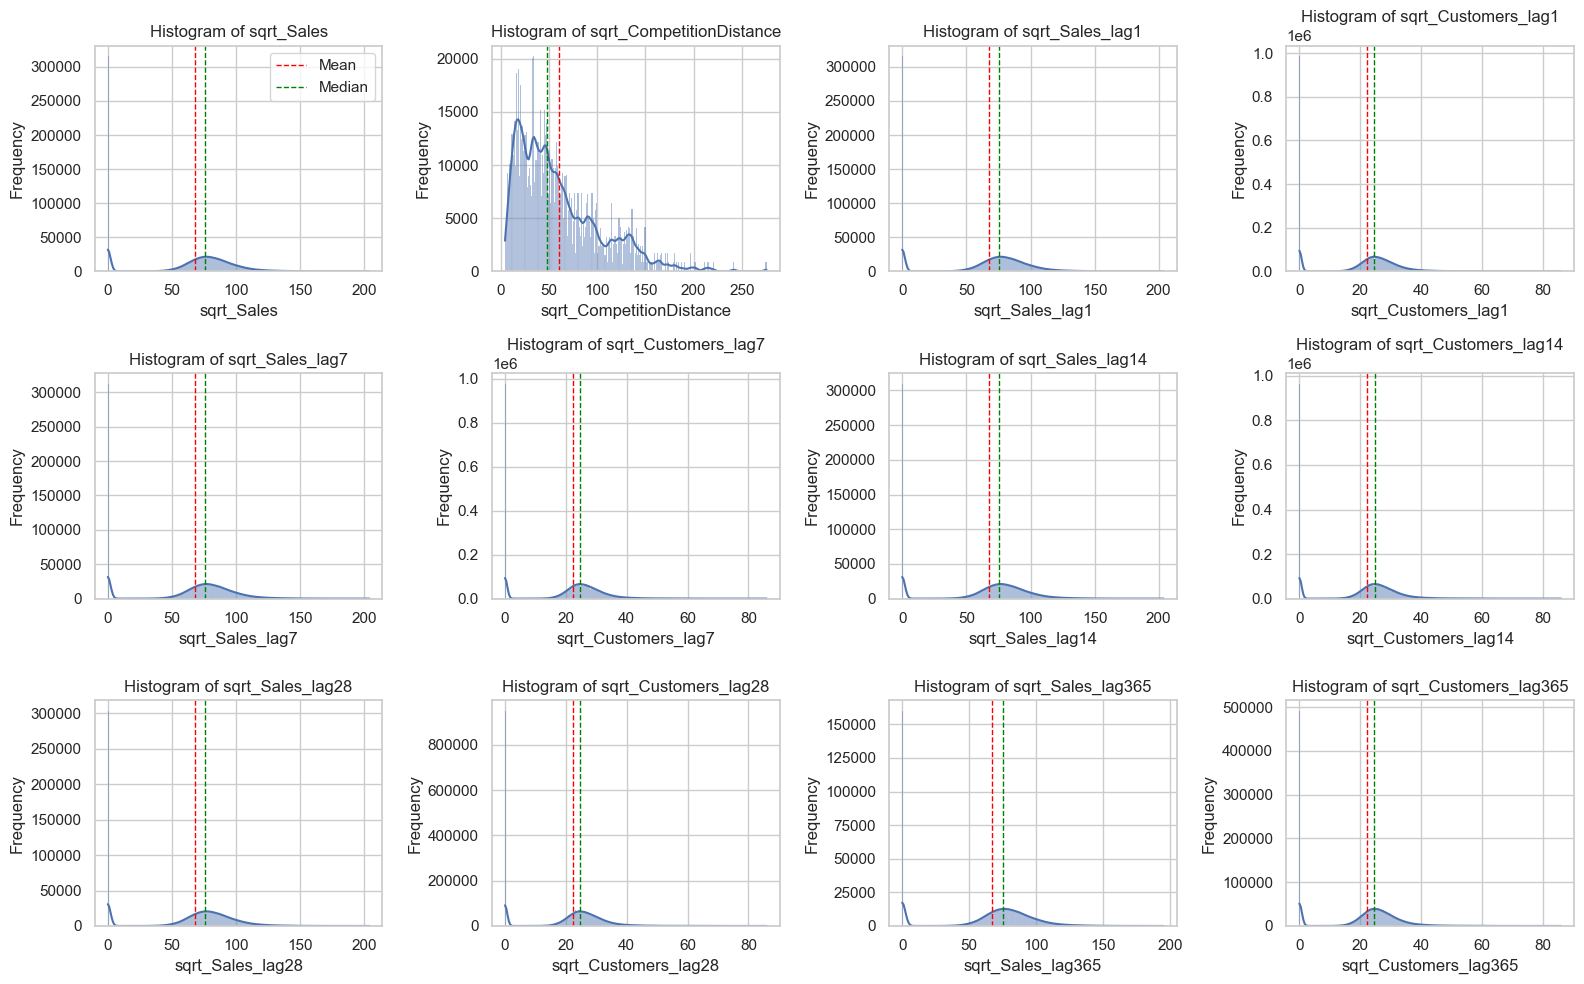

In [96]:
float_feats = df.select_dtypes(include = 'float64').columns
_ = plot_hist_grid(df, float_feats, include_feature_summary=False)

### 🔧 Refining the Transformation

We can see that **`CompetitionDistance`** improved after the last transformation,  
but it still needs further adjustment.

➡️ **Next step:** Apply the **4th root transformation** to `CompetitionDistance`  
to stabilize its distribution even more.


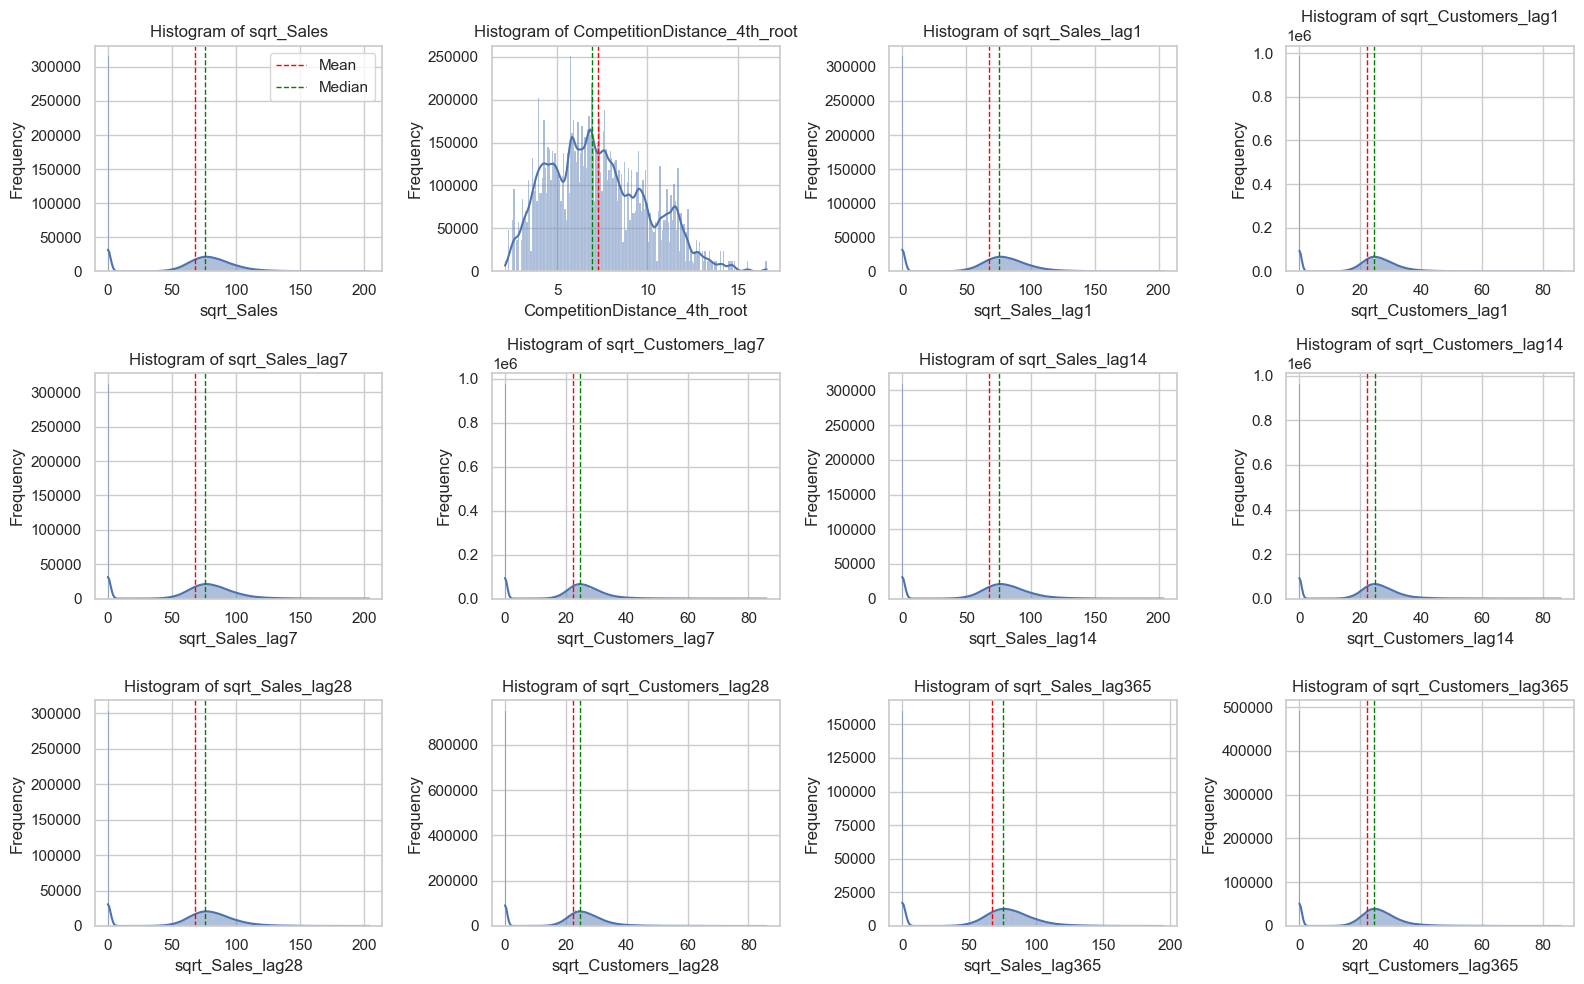

In [97]:
df['sqrt_CompetitionDistance'] = np.sqrt(df['sqrt_CompetitionDistance'])
df = df.rename(columns= {'sqrt_CompetitionDistance': 'CompetitionDistance_4th_root'})

float_feats = df.select_dtypes(include = 'float64').columns
_ = plot_hist_grid(df, float_feats, include_feature_summary=False)

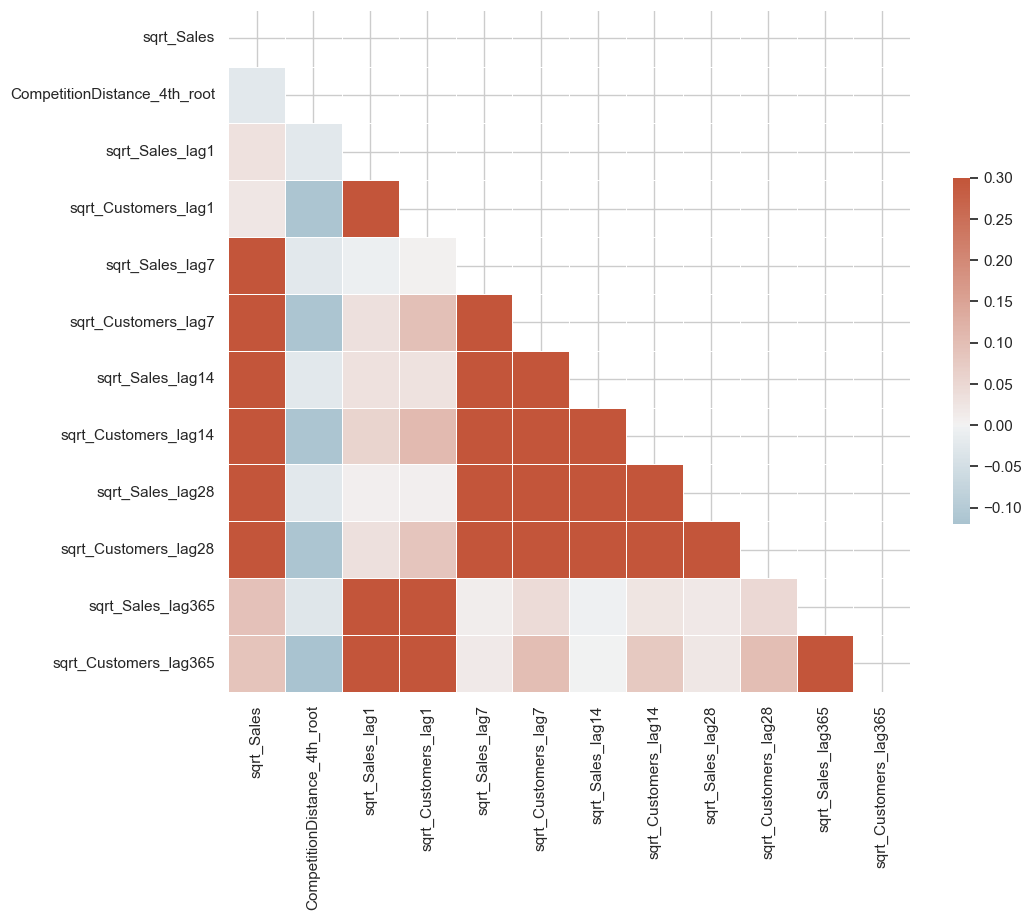

In [98]:
sns.set_theme(style = 'whitegrid')

num_cols = df.select_dtypes(include = 'float64').columns.drop('sqrt_Sales')

# calculate correlation matrix
corr = df.select_dtypes(include = 'float64').corr()
# create mask to make matrix diagonal
mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5},
            xticklabels=corr.columns, yticklabels=corr.columns)

plt.show()

In [99]:
cm = corr * mask

# Get features correlated with sqrt_Sales
high_corr_cols = (
    cm.columns[abs(cm.loc['sqrt_Sales']) >= 0.15]
    .drop('sqrt_Sales')
    .tolist()
)

print("\n📊 Numeric features with correlation ≥ 0.15 to sqrt_Sales:\n")

# Build a nice table with feature + correlation
corr_table = (
    cm.loc['sqrt_Sales', high_corr_cols]
    .sort_values(ascending=False)
    .reset_index()
)

corr_table.columns = ["Feature", "Correlation"]

print(corr_table.to_string(index=False))


📊 Numeric features with correlation ≥ 0.15 to sqrt_Sales:

             Feature  Correlation
    sqrt_Sales_lag14     0.788092
    sqrt_Sales_lag28     0.785821
sqrt_Customers_lag28     0.770749
sqrt_Customers_lag14     0.768264
 sqrt_Customers_lag7     0.747854
     sqrt_Sales_lag7     0.744411


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1017209 entries, 2013-01-01 to 2015-07-31
Data columns (total 49 columns):
 #   Column                            Non-Null Count    Dtype   
---  ------                            --------------    -----   
 0   Store                             1017209 non-null  category
 1   DayOfWeek                         1017209 non-null  int64   
 2   sqrt_Sales                        1017209 non-null  float64 
 3   Open                              1017209 non-null  int64   
 4   Promo                             1017209 non-null  int64   
 5   StateHoliday                      1017209 non-null  int64   
 6   SchoolHoliday                     1017209 non-null  int64   
 7   StoreType                         1017209 non-null  object  
 8   Assortment                        1017209 non-null  object  
 9   CompetitionDistance_4th_root      1014567 non-null  float64 
 10  CompetitionOpenSinceYear          1017209 non-null  int64   
 11  Promo2   

In [101]:
modeling_cols = ['Store'] + df.select_dtypes(include = 'int64').columns.tolist() + high_corr_cols +['sqrt_Sales']
modeling_cols

['Store',
 'DayOfWeek',
 'Open',
 'Promo',
 'StateHoliday',
 'SchoolHoliday',
 'CompetitionOpenSinceYear',
 'Promo2',
 'Promo2SinceWeek',
 'Promo2SinceYear',
 'Competition_open_since_August',
 'Competition_open_since_December',
 'Competition_open_since_February',
 'Competition_open_since_January',
 'Competition_open_since_July',
 'Competition_open_since_June',
 'Competition_open_since_March',
 'Competition_open_since_May',
 'Competition_open_since_November',
 'Competition_open_since_October',
 'Competition_open_since_September',
 'Promo2_Interval_in_Aug',
 'Promo2_Interval_in_Dec',
 'Promo2_Interval_in_Feb',
 'Promo2_Interval_in_Jan',
 'Promo2_Interval_in_Jul',
 'Promo2_Interval_in_Jun',
 'Promo2_Interval_in_Mar',
 'Promo2_Interval_in_May',
 'Promo2_Interval_in_Nov',
 'Promo2_Interval_in_Oct',
 'Promo2_Interval_in_Sept',
 'sqrt_Sales_lag7',
 'sqrt_Customers_lag7',
 'sqrt_Sales_lag14',
 'sqrt_Customers_lag14',
 'sqrt_Sales_lag28',
 'sqrt_Customers_lag28',
 'sqrt_Sales']

In [102]:
df = df[modeling_cols]

num_cols = df.select_dtypes(include = 'float64').columns.tolist()
num_cols

['sqrt_Sales_lag7',
 'sqrt_Customers_lag7',
 'sqrt_Sales_lag14',
 'sqrt_Customers_lag14',
 'sqrt_Sales_lag28',
 'sqrt_Customers_lag28',
 'sqrt_Sales']

In [103]:
x_scaler = StandardScaler()
x_scaler.fit(df[num_cols])
df[num_cols] = x_scaler.transform(df[num_cols])

y_scaler = StandardScaler()
y_scaler.fit(df['sqrt_Sales'].to_numpy().reshape(-1,1) )
df['sqrt_Sales'] = y_scaler.transform(df['sqrt_Sales'].to_numpy().reshape(-1,1)).ravel()

In [104]:
import joblib

joblib.dump(x_scaler, "../artifacts/x_scaler.joblib")
joblib.dump(x_scaler, "../artifacts/y_scaler.joblib")

['../artifacts/y_scaler.joblib']